In [4]:
# ЭТАП 1: Импортируем нужные библиотеки
import pickle
import numpy as np
from scipy.signal import butter, sosfiltfilt  # ← ВАЖНО: sosfiltfilt, не filtfilt!
import matplotlib.pyplot as plt

# ЭТАП 2: Загружаем данные
with open('model/wesad/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# ЭТАП 3: Извлекаем ECG сигнал
ecg_raw = data['signal']['chest']['ECG'].flatten()

print(f"✅ ECG загружен: shape={ecg_raw.shape}")
print(f"   {len(ecg_raw)} отсчётов = {len(ecg_raw)/700:.1f} сек")

# ЭТАП 4: Создаём фильтр (в формате sos)
sos = butter(4, [0.5, 100], btype='band', fs=700, output='sos')

# ЭТАП 5: Применяем фильтр к ECG
ecg_filtered = sosfiltfilt(sos, ecg_raw)  # ← sosfiltfilt для sos формата!

print(f"\n✅ Фильтр применён!")
print(f"   Было: {len(ecg_raw)} отсчётов")
print(f"   Стало: {len(ecg_filtered)} отсчётов (чистый сигнал)")


✅ ECG загружен: shape=(4255300,)
   4255300 отсчётов = 6079.0 сек

✅ Фильтр применён!
   Было: 4255300 отсчётов
   Стало: 4255300 отсчётов (чистый сигнал)


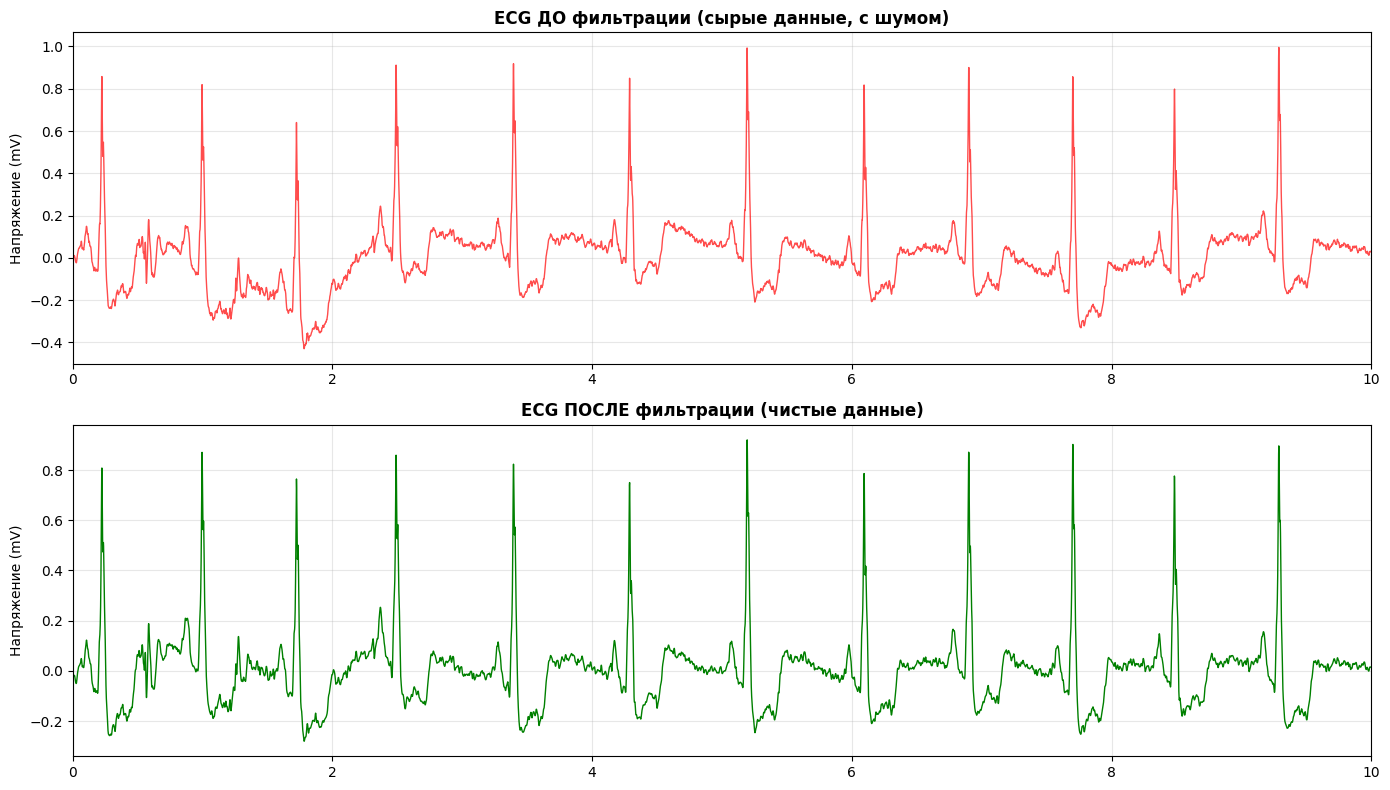

✅ Сохранено: outputs/ecg_before_after_filter.png


In [5]:
# Сравниваем ДО и ПОСЛЕ фильтрации
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# График 1: ДО фильтрации (сырые данные)
time_axis = np.arange(len(ecg_raw[:7000])) / 700
axes[0].plot(time_axis, ecg_raw[:7000], linewidth=1, color='red', alpha=0.7)
axes[0].set_title('ECG ДО фильтрации (сырые данные, с шумом)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Напряжение (mV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 10])

# График 2: ПОСЛЕ фильтрации (чистые данные)
axes[1].plot(time_axis, ecg_filtered[:7000], linewidth=1, color='green')
axes[1].set_title('ECG ПОСЛЕ фильтрации (чистые данные)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Напряжение (mV)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 10])

plt.tight_layout()
plt.savefig('outputs/ecg_before_after_filter.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Сохранено: outputs/ecg_before_after_filter.png")


In [6]:
print("\n📊 СТАТИСТИКА ФИЛЬТРАЦИИ:")
print(f"\nДО фильтрации (ECG сырой):")
print(f"  Mean: {np.mean(ecg_raw):.6f} mV")
print(f"  Std:  {np.std(ecg_raw):.6f} mV")
print(f"  Min:  {np.min(ecg_raw):.6f} mV")
print(f"  Max:  {np.max(ecg_raw):.6f} mV")

print(f"\nПОСЛЕ фильтрации (ECG чистый):")
print(f"  Mean: {np.mean(ecg_filtered):.6f} mV")
print(f"  Std:  {np.std(ecg_filtered):.6f} mV")
print(f"  Min:  {np.min(ecg_filtered):.6f} mV")
print(f"  Max:  {np.max(ecg_filtered):.6f} mV")

print(f"\n✅ Фильтр убрал шум, сохранив сердечные волны!")



📊 СТАТИСТИКА ФИЛЬТРАЦИИ:

ДО фильтрации (ECG сырой):
  Mean: 0.001212 mV
  Std:  0.154077 mV
  Min:  -1.499542 mV
  Max:  1.499313 mV

ПОСЛЕ фильтрации (ECG чистый):
  Mean: 0.000000 mV
  Std:  0.152511 mV
  Min:  -1.542615 mV
  Max:  1.724970 mV

✅ Фильтр убрал шум, сохранив сердечные волны!
